In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from rasterstats import zonal_stats
from shapely.geometry import Point

In [2]:
gdf_road=gpd.read_file('road.geojson')
gdf_pois_public_service=gpd.read_file('gdf_pois_public_service.geojson')

In [3]:
gdf_district=gpd.read_file(r'G:\数据分析作品集\广州市.geojson')

Skipping field center: unsupported OGR type: 3
Skipping field centroid: unsupported OGR type: 3
Skipping field acroutes: unsupported OGR type: 1


In [4]:
gdf_core_area=gpd.read_file('gz_central_area.geojson')

In [5]:
crs_proj = "EPSG:32650"  
crs_wgs84 = "EPSG:4326"

In [6]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [7]:
gdf_road_proj=gdf_road.to_crs(crs_proj)
gdf_pois_public_service_proj=gdf_pois_public_service.to_crs(crs_proj)
gdf_district_proj=gdf_district.to_crs(crs_proj)
gdf_core_area_proj=gdf_core_area.to_crs(crs_proj)

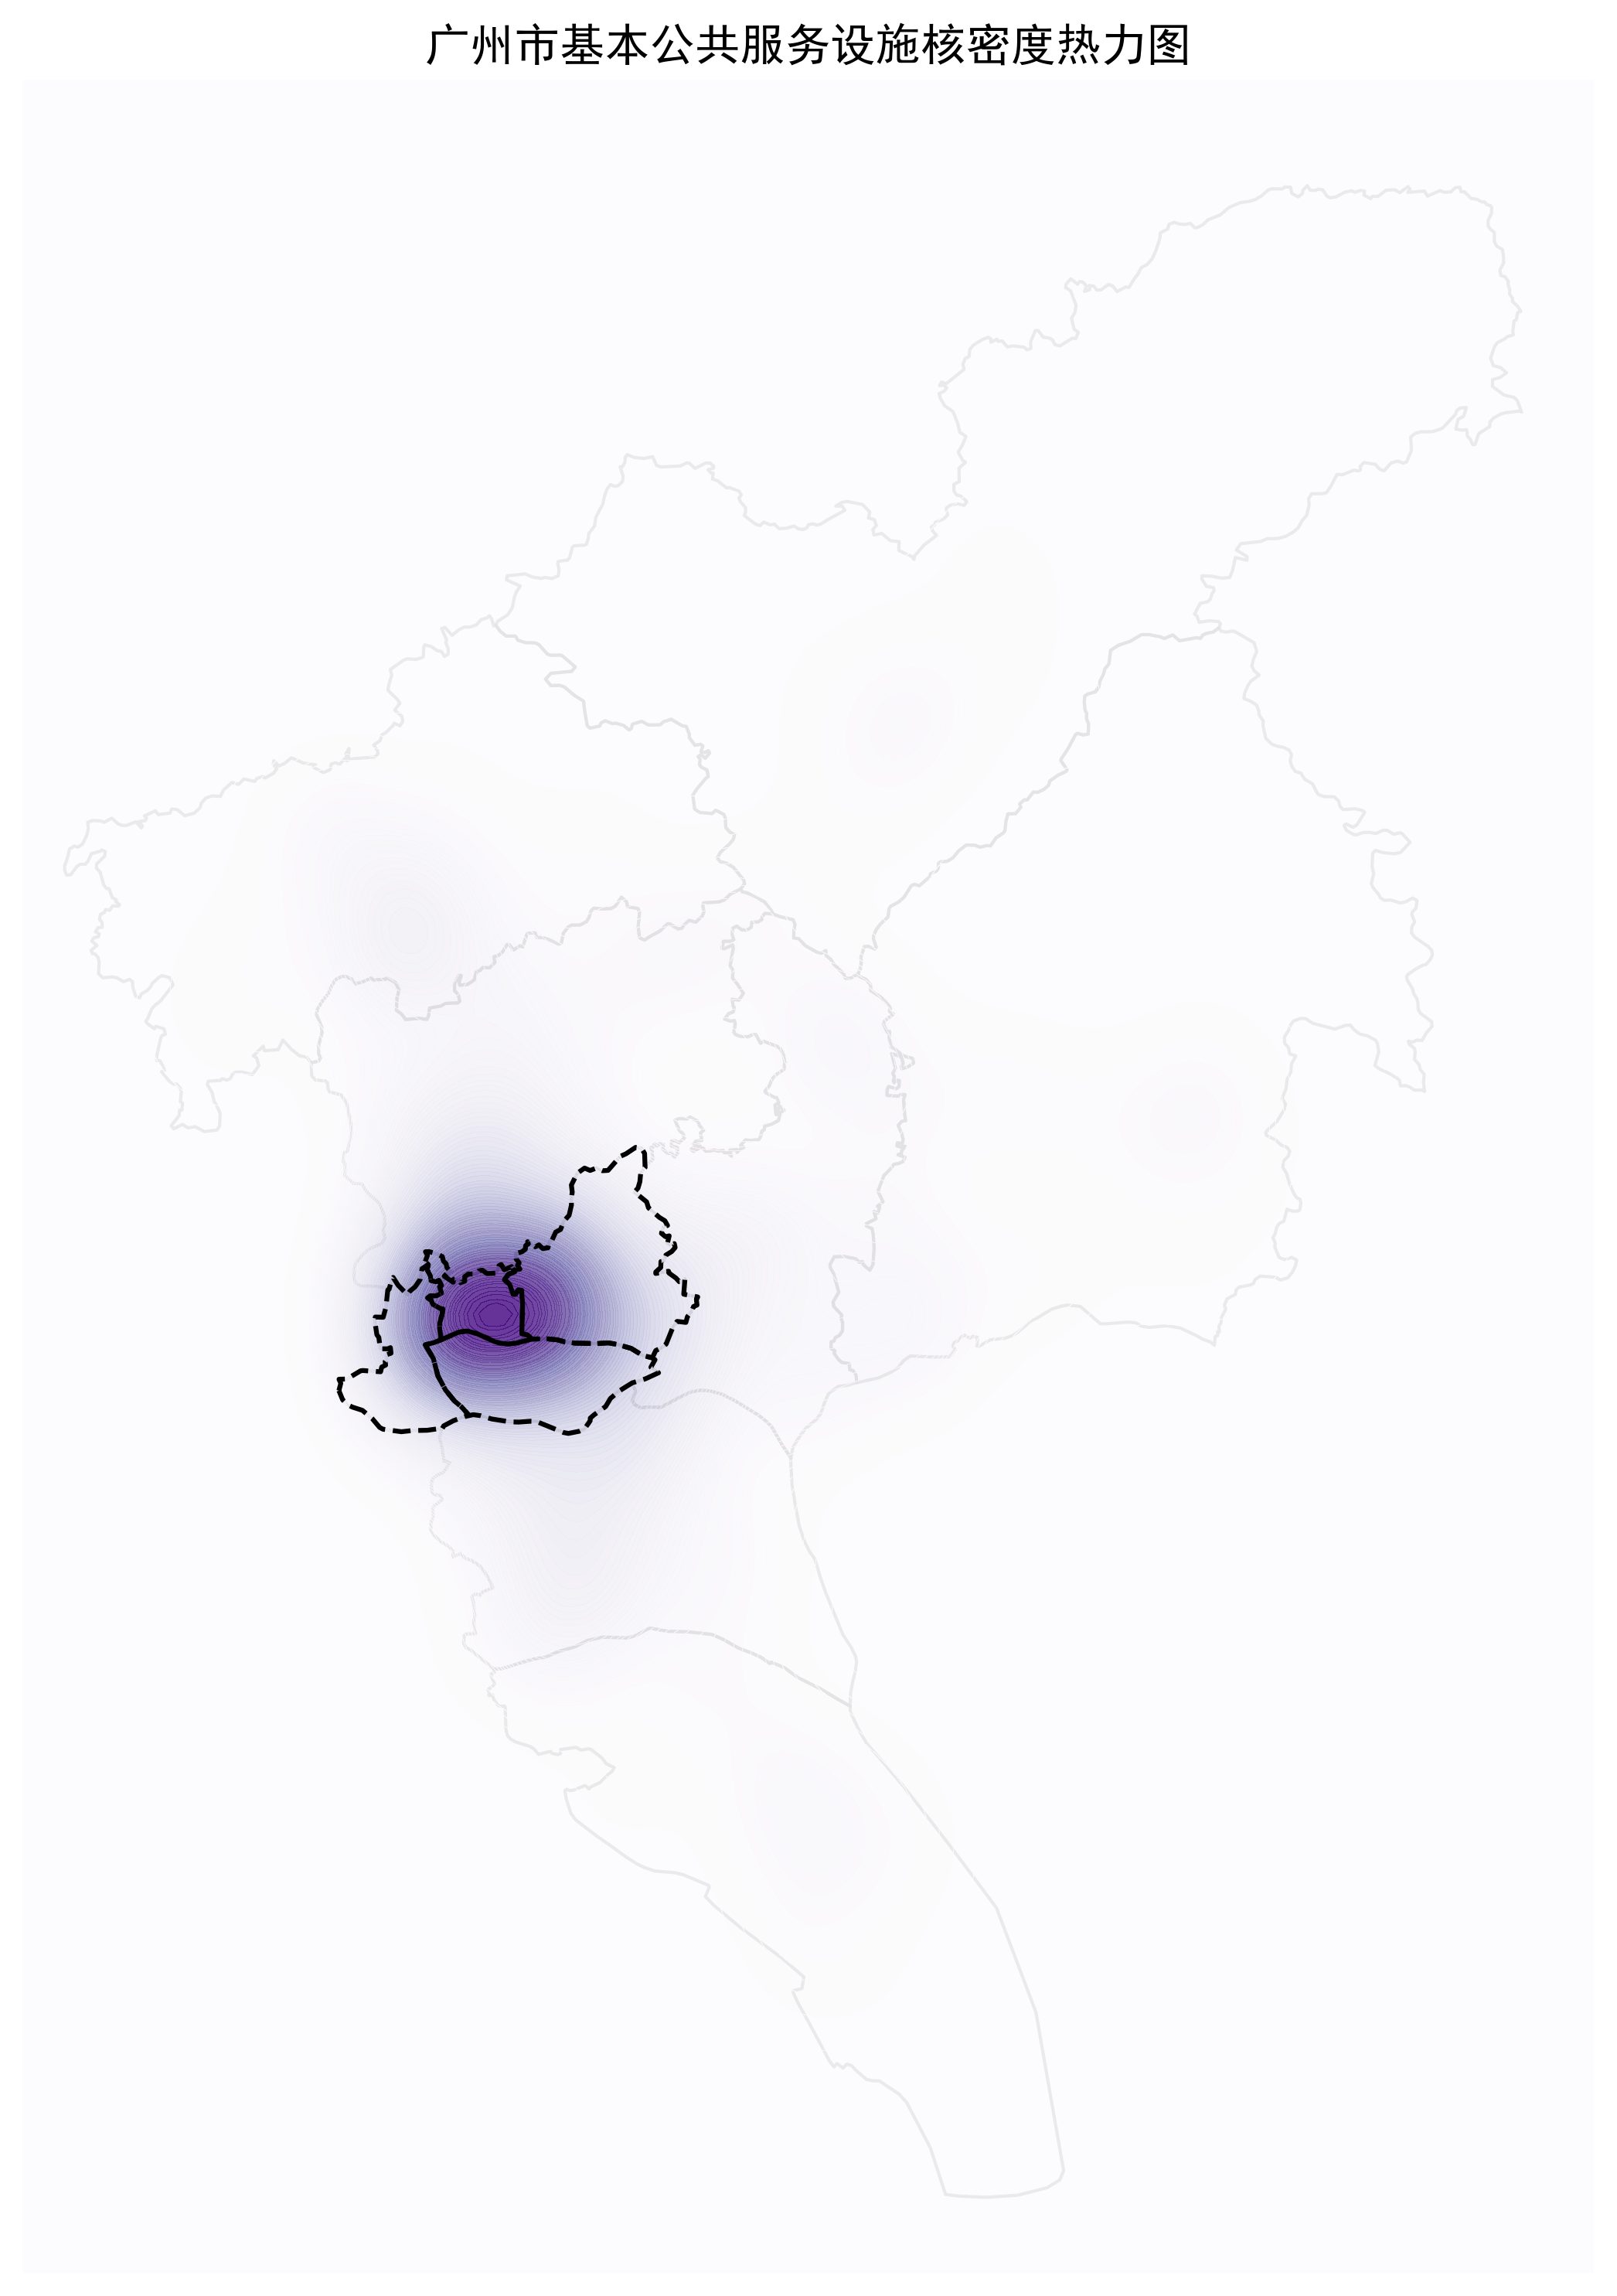

In [8]:
fig,ax=plt.subplots(figsize=(12,10),dpi=300)

gdf_district_proj.plot(ax=ax,facecolor='none',edgecolor='gray',linewidth=1,alpha=0.7)
sns.kdeplot(
    data=gdf_pois_public_service_proj,
    x=gdf_pois_public_service_proj.geometry.x,
    y=gdf_pois_public_service_proj.geometry.y,
    cmap='Purples',
    fill=True,
    thresh=0,
    levels=100,
    alpha=0.8,
    ax=ax
)
gdf_core_area_proj.plot(ax=ax,facecolor='none',edgecolor='black', linewidth=1.5, linestyle='--')

ax.set_title("广州市基本公共服务设施核密度热力图", fontsize=14, fontweight='bold')
ax.set_xlabel("投影坐标X", fontsize=10)
ax.set_ylabel("投影坐标Y", fontsize=10)
ax.axis('off')  
plt.tight_layout()


plt.savefig("公共服务设施核密度热力图.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
from shapely.geometry import Polygon

In [10]:
walk_speed = 80  # 每分钟步行80米
walk_time = 15   # 15分钟生活圈
buffer_distance = walk_speed * walk_time 

In [11]:
gdf_service_buffer = gdf_pois_public_service_proj.copy()
gdf_service_buffer['geometry'] = gdf_service_buffer.buffer(buffer_distance)
# 融合所有缓冲区，消除重叠，得到全域服务覆盖面
gdf_buffer_union = gdf_service_buffer.dissolve().reset_index(drop=True)

In [12]:
xmin, ymin, xmax, ymax = gdf_district_proj.total_bounds
grid_size = 1000 
x_coords = np.arange(xmin, xmax, grid_size)
y_coords = np.arange(ymin, ymax, grid_size)

polygons = []
grid_ids = []
for i, x in enumerate(x_coords):
    for j, y in enumerate(y_coords):
        polygons.append(Polygon([(x, y), (x+grid_size, y), (x+grid_size, y+grid_size), (x, y+grid_size)]))
        grid_ids.append(f"网格_{i}_{j}")

gdf_grid = gpd.GeoDataFrame(
    {"网格ID": grid_ids, "geometry": polygons},
    crs=crs_proj
)

gdf_grid = gpd.overlay(gdf_grid, gdf_district_proj, how='intersection')


In [13]:
gdf_grid['grid_area'] = gdf_grid.area

In [14]:
# 空间叠加，计算每个网格被缓冲区覆盖的面积
gdf_grid_cover = gpd.overlay(gdf_grid, gdf_buffer_union, how='intersection')
gdf_grid_cover['cover_area'] = gdf_grid_cover.area

In [15]:
# 合并回主网格表，计算覆盖比例
gdf_grid = gdf_grid.merge(
    gdf_grid_cover[['网格ID', 'cover_area']],
    on='网格ID',
    how='left'
)
gdf_grid['cover_area'] = gdf_grid['cover_area'].fillna(0)
gdf_grid['cover_rate'] = gdf_grid['cover_area'] / gdf_grid['grid_area']

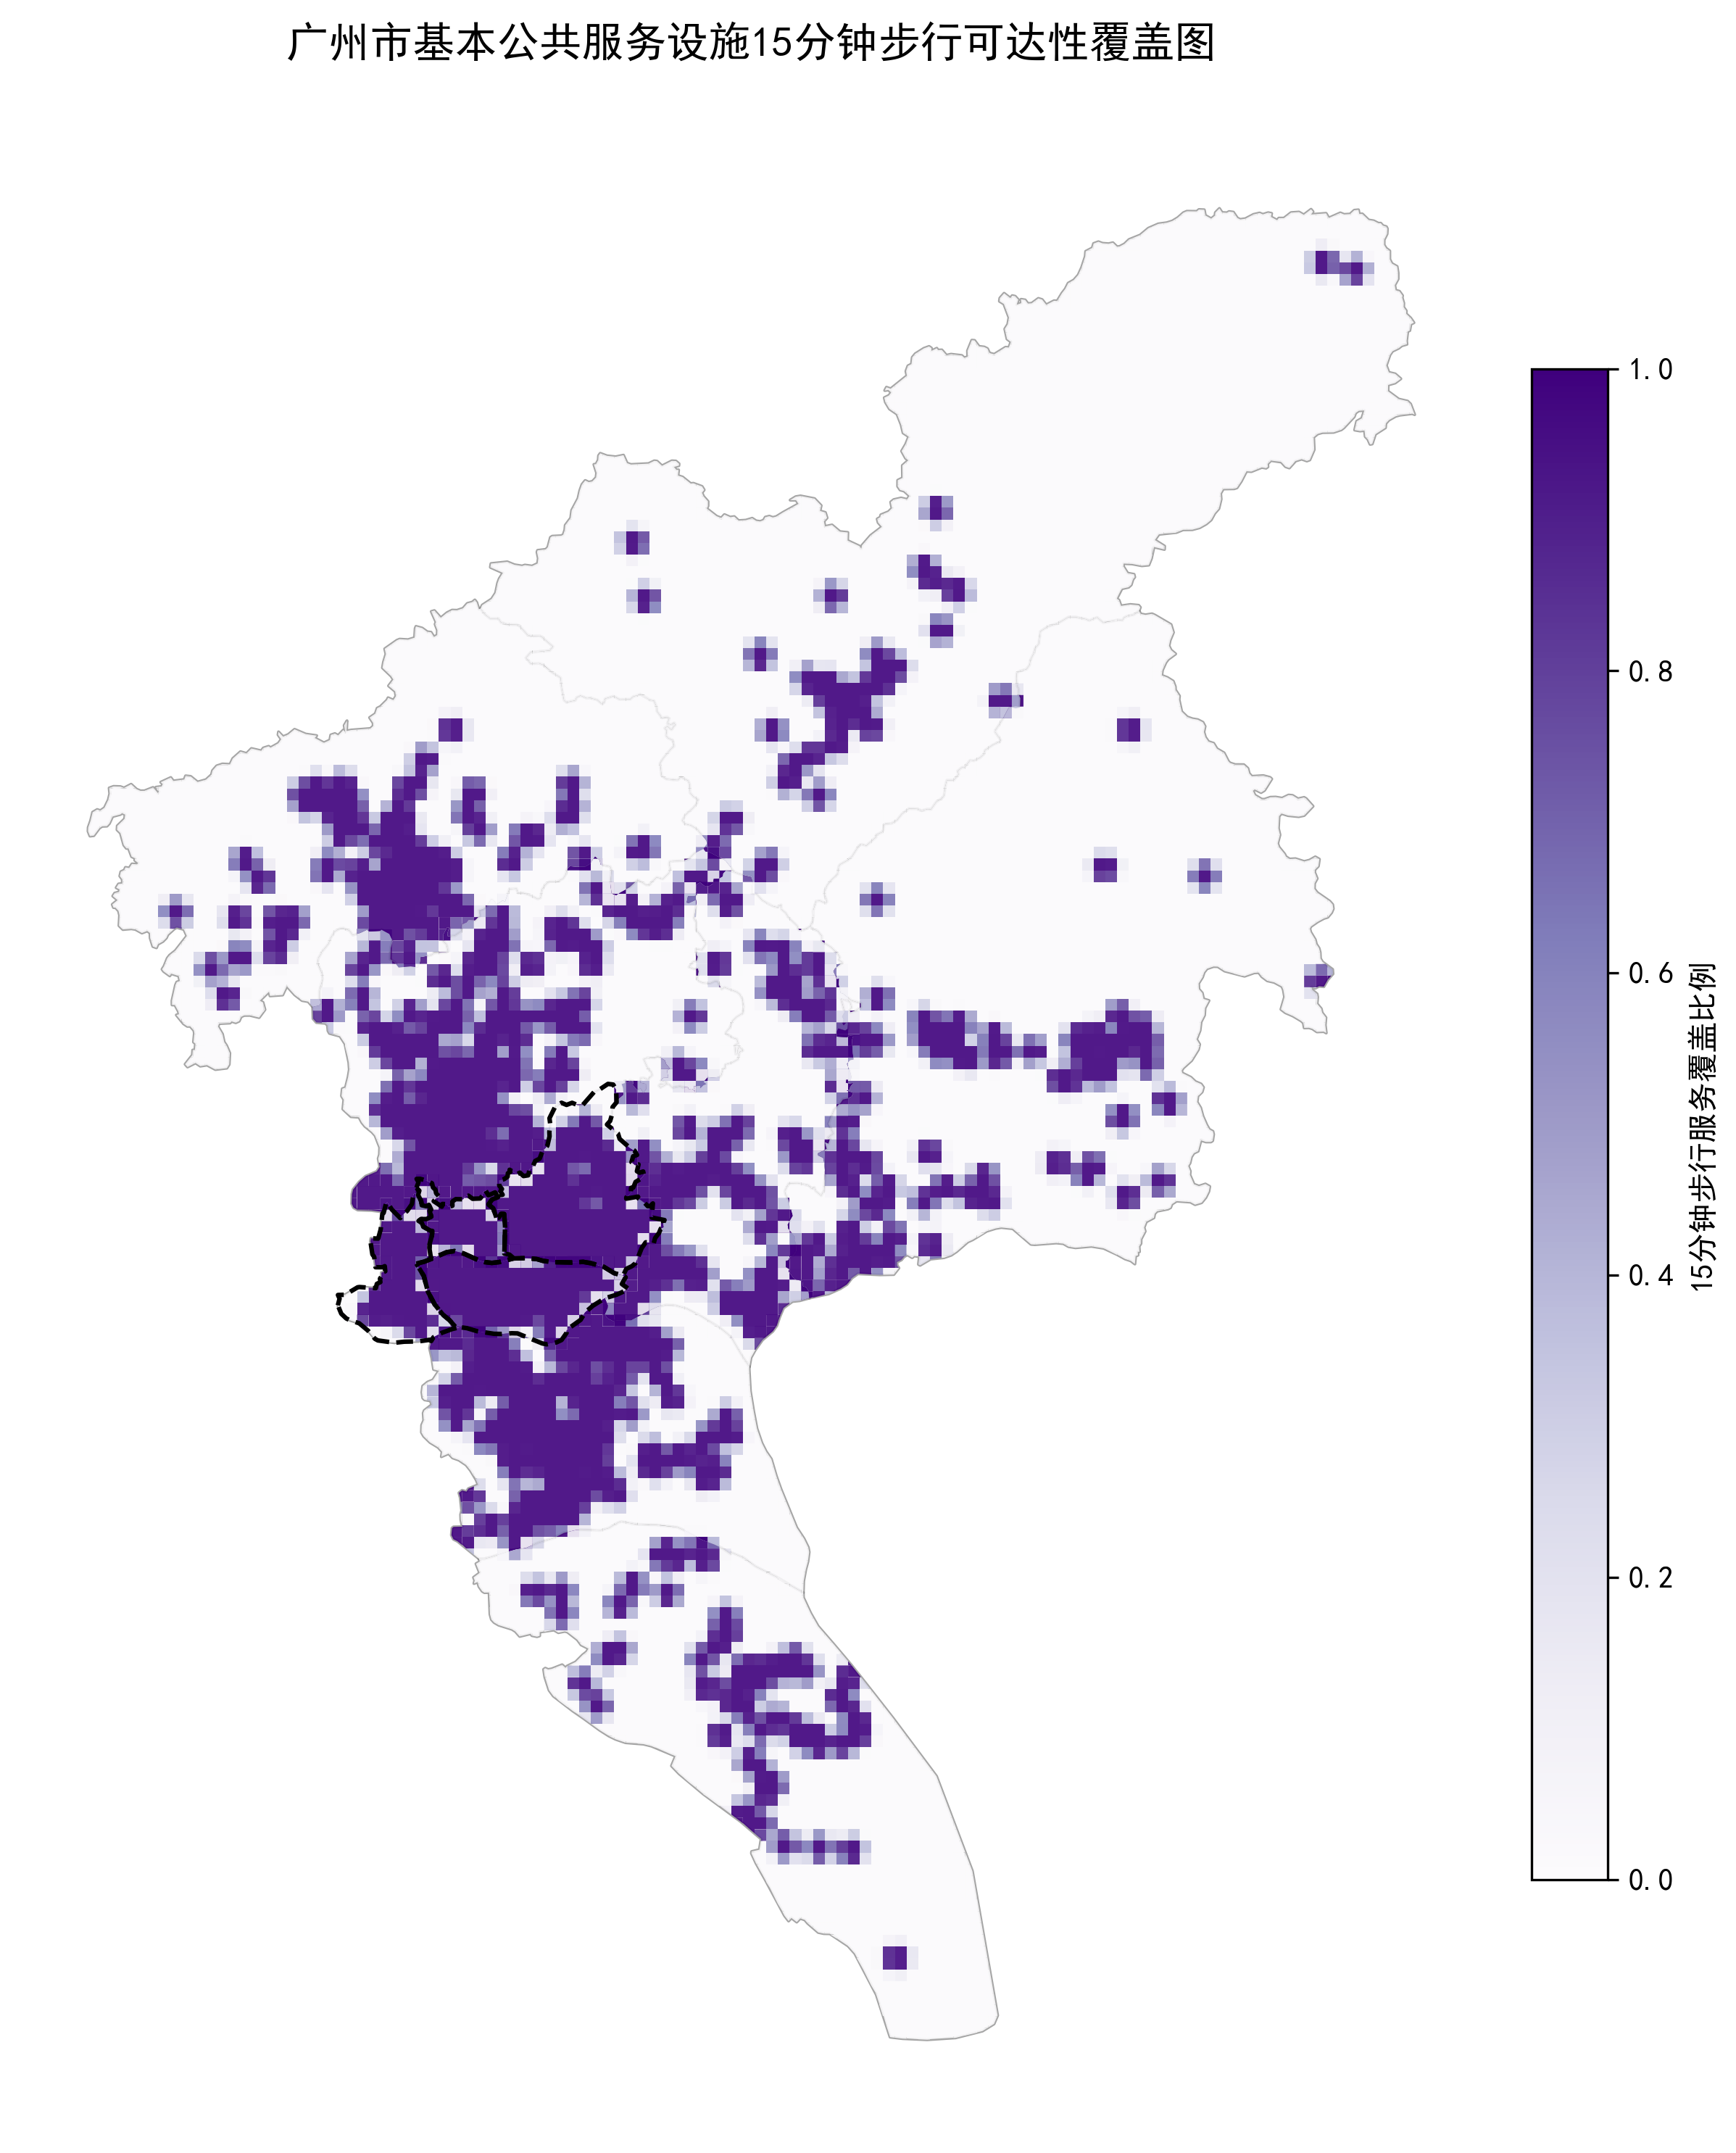

In [16]:
from matplotlib.colors import LinearSegmentedColormap

fig, ax = plt.subplots(figsize=(12, 10), dpi=300)
# 底图：行政区边界
gdf_district_proj.plot(
    ax=ax,
    facecolor='#f8f8f8',
    edgecolor='gray',
    linewidth=1,
    alpha=0.7
)
# 核心图层：覆盖比例可视化，关闭网格边框，消除方块感
gdf_grid.plot(
    ax=ax,
    column='cover_rate',
    cmap='Purples',
    vmin=0,
    vmax=1,
    edgecolor='none',  # 关闭网格边框，画面更平滑
    alpha=0.9,
    legend=True,
    legend_kwds={
        'label': '15分钟步行服务覆盖比例',
        'shrink': 0.75,
        'pad': 0.02
    }
)
# 核心区虚线框置顶
gdf_core_area_proj.plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    linewidth=1.5,
    linestyle='--',
    zorder=10
)
# 标题与格式
ax.set_title(
    '广州市基本公共服务设施15分钟步行可达性覆盖图',
    fontsize=14,
    fontweight='bold',
    pad=20
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('可达性覆盖图_优化版.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [17]:
import rasterio
from rasterio.warp import reproject, Resampling, calculate_default_transform
from rasterio.windows import from_bounds
import rioxarray as rrx

In [18]:
landscan_path = r'G:\数据分析作品集\人口栅格数据\landscan-global-2024.tif'
gdf_district_wgs84 = gdf_district_proj.to_crs(crs_wgs84)
bounds = gdf_district_wgs84.total_bounds

with rasterio.open(landscan_path) as src:
    # 1. 先读取窗口数据
    window = from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], src.transform)
    window = window.round_offsets().round_lengths()
    
    data = src.read(1, window=window, masked=True).astype('float32')
    
    # 2. 计算重投影参数，强制限制输出尺寸
    dst_crs = crs_proj  # 你的目标CRS
    
    # 计算默认变换
    dst_transform, dst_width, dst_height = calculate_default_transform(
        src.crs, dst_crs, window.width, window.height,
        *rasterio.windows.bounds(window, src.transform)
    )
    
    print(f"默认输出尺寸: {dst_width} x {dst_height}")
    
    # 如果太大，强制缩放
    max_size = 8000  # 最大尺寸
    if dst_width > max_size or dst_height > max_size:
        scale = max(dst_width, dst_height) / max_size
        dst_width = int(dst_width / scale)
        dst_height = int(dst_height / scale)
        # 重新计算 transform
        dst_transform = dst_transform * dst_transform.scale(scale, scale)
        print(f"调整后: {dst_width} x {dst_height}")
    
    # 3. 创建输出数组并执行重投影
    dst_data = np.zeros((dst_height, dst_width), dtype='float32')
    
    reproject(
        source=data,
        destination=dst_data,
        src_transform=rasterio.windows.transform(window, src.transform),
        src_crs=src.crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear,
        nodata=0
    )
    
    # 转换为 xarray 便于后续处理
    import xarray as xr
    landscan_gz_proj = xr.DataArray(
    dst_data,
    dims=["y", "x"],
    coords={
        "y": np.arange(dst_height) * dst_transform.e + dst_transform.f,
        "x": np.arange(dst_width) * dst_transform.a + dst_transform.c
    }
)
landscan_gz_proj = landscan_gz_proj.rio.write_crs(crs_proj)

# 3. 【核心修复2】正确绑定空间维度和变换信息
landscan_gz_proj = landscan_gz_proj.rio.set_spatial_dims(x_dim="x", y_dim="y")
landscan_gz_proj = landscan_gz_proj.rio.write_transform(dst_transform)

# 4. 【验证】必须输出EPSG:32650才算绑定成功
print(f"✅ DataArray CRS验证：{landscan_gz_proj.rio.crs}")
print(f"✅ 空间维度验证：x={landscan_gz_proj.rio.x_dim}, y={landscan_gz_proj.rio.y_dim}")
print(f"✅ 栅格范围验证：{landscan_gz_proj.rio.bounds()}")
print(f"✅ 栅格非0值验证：总非0像元数={np.count_nonzero(landscan_gz_proj.values)}，最大值={landscan_gz_proj.max().item()}")

默认输出尺寸: 130 x 178
✅ DataArray CRS验证：EPSG:32650
✅ 空间维度验证：x=x, y=y
✅ 栅格范围验证：(83649.26738311611, 2493297.209170791, 200424.57511019026, 2653189.553597092)
✅ 栅格非0值验证：总非0像元数=21360，最大值=52160.03125


In [ ]:
gdf_grid = gdf_grid.to_crs(crs_proj)

# ---------------------- 核心：用 xarray 快速统计栅格均值/总和 ----------------------
def zonal_stats_xr(gdf, raster, stats="sum"):
    values = []
    raster_bounds = raster.rio.bounds()
    
    for idx, geom in gdf.geometry.items():
        try:
            geom_bounds = geom.bounds
            if (geom_bounds[2] < raster_bounds[0] or geom_bounds[0] > raster_bounds[2] or
                geom_bounds[3] < raster_bounds[1] or geom_bounds[1] > raster_bounds[3]):
                values.append(0)
                continue
            
            # 裁剪栅格，drop=True自动剔除空区域
            clipped = raster.rio.clip([geom], gdf.crs, all_touched=True, drop=True)
            
            # 统计数值，过滤nodata和0值
            valid_data = clipped.where(clipped > 0, drop=True)
            if stats == "sum":
                val = valid_data.sum().item()
            else:
                val = valid_data.mean().item()
            
            values.append(val if not np.isnan(val) else 0)
        except:
            values.append(0)
    return values

# 执行统计
print("正在统计每个网格的总人口...")
gdf_grid["total_population"] = zonal_stats_xr(gdf_grid, landscan_gz_proj, stats="sum")

# 查看结果（必须出现非0值）
print("✅ 网格人口统计完成！")
print("=== 人口Top10网格 ===")
print(gdf_grid[["网格ID", "total_population"]].sort_values("total_population", ascending=False).head(10))


正在统计每个网格的总人口...


In [ ]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=300)

# 1. 底图：先叠加淡灰色道路网

gdf_road_proj.plot(
    ax=ax,
    color='#f0f0f0',
    linewidth=0.3,
    alpha=0.5
)

# 2. 行政区边界（加深灰度，提升轮廓感）
gdf_district_proj.plot(
    ax=ax,
    facecolor='none',
    edgecolor='#666666',
    linewidth=1.2,
    alpha=0.7
)

# 3. 核心图层：网格人口分布
# 关键1：vmax用98分位数，剔除极值干扰，拉开中低值的层次
# 关键2：关闭网格边界线，消除方块感
# 关键3：调整透明度，让底图道路透出来，提升空间感
pop_max = np.percentile(gdf_grid['total_population'], 98)
gdf_grid.plot(
    ax=ax,
    column='total_population',
    cmap='Purples',
    vmin=0,
    vmax=pop_max,
    edgecolor='none',  # 关闭网格边界，消除方块感
    alpha=0.9,
    legend=True,
    legend_kwds={
        'label': '1km网格总人口数（LandScan）',
        'shrink': 0.75,  # 缩小图例，适配画布
        'pad': 0.02,     # 调整图例和画布的间距
        'orientation': 'vertical'
    }
)

# 4. 核心区边界
gdf_core_area_proj.plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    linewidth=1.8,
    linestyle='--'
)

# 5. 标题与格式优化
ax.set_title(
    '广州市1km网格人口分布图（基于LandScan数据）',
    fontsize=14,
    fontweight='bold',
    pad=20  
)
ax.set_axis_off()  # 关闭坐标轴
plt.tight_layout()  # 自动适配排版，避免元素被截断

# 保存图片
plt.savefig('广州市网格人口分布_优化版.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# ---------------------- 1. 前置处理：保留所有网格，无人区单独标记 ----------------------
# 不再过滤无人区，而是把无人区单独标记为「无需求」，保证图面完整
gdf_grid_valid = gdf_grid.copy()

# ---------------------- 2. 需求指数优化：基于人口密度，更贴合公共服务的需求逻辑 ----------------------
# 公共服务的需求是「人口密度」，不是绝对人口数，避免大网格的干扰
gdf_grid_valid['pop_density'] = gdf_grid_valid['total_population'] / (gdf_grid_valid['grid_area'] / 1e6)  # 人/平方公里

# 用95分位数截断极值，避免超大型社区拉垮标准化，同时保留0值（无人区）
pop_95 = np.percentile(gdf_grid_valid['pop_density'], 95)
gdf_grid_valid['demand_index'] = np.clip(gdf_grid_valid['pop_density'], 0, pop_95)
# 标准化：仅对有人口的网格做标准化，无人区demand_index=0
has_pop = gdf_grid_valid['total_population'] > 0
gdf_grid_valid.loc[has_pop, 'demand_index'] = (
    (gdf_grid_valid.loc[has_pop, 'demand_index'] - gdf_grid_valid.loc[has_pop, 'demand_index'].min()) 
    / (gdf_grid_valid.loc[has_pop, 'demand_index'].max() - gdf_grid_valid.loc[has_pop, 'demand_index'].min())
)

In [ ]:
# ---------------------- 3. 供给指数优化：以覆盖比例为核心，POI数量做辅助，权重更合理 ----------------------
# 公共服务的核心是「有没有覆盖到」，其次才是「数量多少」，避免POI数量权重过大
# 先统计每个网格内的POI数量
gdf_grid_with_poi = gpd.sjoin(
    gdf_grid_valid,
    gdf_pois_public_service_proj[['geometry']],
    how='left',
    predicate='contains'
)


In [ ]:
poi_count = gdf_grid_with_poi.groupby('网格ID').size().reset_index(name='poi_count')
gdf_grid_valid = gdf_grid_valid.merge(poi_count, on='网格ID', how='left')
gdf_grid_valid['poi_count'] = gdf_grid_valid['poi_count'].fillna(0)

In [ ]:
# 供给指数 = 覆盖比例（核心权重70%） + POI密度（辅助权重30%）
gdf_grid_valid['poi_density'] = gdf_grid_valid['poi_count'] / (gdf_grid_valid['grid_area'] / 1e6)
poi_density_95 = np.percentile(gdf_grid_valid['poi_density'], 95)
gdf_grid_valid['poi_density_norm'] = np.clip(gdf_grid_valid['poi_density'], 0, poi_density_95)
gdf_grid_valid['poi_density_norm'] = (gdf_grid_valid['poi_density_norm'] - gdf_grid_valid['poi_density_norm'].min()) / (gdf_grid_valid['poi_density_norm'].max() - gdf_grid_valid['poi_density_norm'].min())

# 最终供给指数（0-1）
gdf_grid_valid['supply_index'] = 0.7 * gdf_grid_valid['cover_rate'] + 0.3 * gdf_grid_valid['poi_density_norm']

In [ ]:
# ---------------------- 4. 缺口指数优化：用供需比，逻辑更严谨，无异常值 ----------------------
# 核心逻辑：供需比 = 供给指数 / (需求指数 + 1e-6)
# 供需比 < 1 → 供给 < 需求 → 有缺口，数值越小缺口越严重
# 供需比 ≥ 1 → 供给 ≥ 需求 → 覆盖良好
gdf_grid_valid['supply_demand_ratio'] = gdf_grid_valid['supply_index'] / (gdf_grid_valid['demand_index'] + 1e-6)

# 对有人口的网格，计算缺口指数（0=缺口最严重，1=覆盖最好）
# 【核心修复】用1.0替代1，初始化为浮点型，允许写入小数
gdf_grid_valid['gap_index'] = 1.0  
# 有人口的网格，用供需比计算缺口指数，截断到0-1，确保浮点类型
gdf_grid_valid.loc[has_pop, 'gap_index'] = np.clip(
    gdf_grid_valid.loc[has_pop, 'supply_demand_ratio'].astype('float64'), 
    0, 
    1
)

In [ ]:
# ---------------------- 5. 缺口分级：用分位数分级，贴合数据分布，保证每个级别都有样本 ----------------------
# 分级逻辑：gap_index越小，缺口越严重
# 用分位数设置阈值，保证4个级别都有合理的样本量，不会出现99%集中在一个级别
# 阈值说明：
# 0-0.2 → 重度缺口（供需比<0.2，需求远大于供给，优先改善，占比约10%）
# 0.2-0.5 → 中度缺口（供需比0.2-0.5，需求大于供给，需要改善，占比约20%）
# 0.5-0.8 → 基本平衡（供需比0.5-0.8，供需基本匹配，占比约30%）
# 0.8-1.0 → 覆盖良好（供需比≥0.8，供给充足，占比约40%）
def get_gap_level(row):
    # 无人区：无需求，标记为无需求
    if row['total_population'] == 0:
        return '无需求（无人区）'
    elif row['gap_index'] <= 0.2:
        return '重度缺口（优先改善）'
    elif row['gap_index'] <= 0.5:
        return '中度缺口'
    elif row['gap_index'] <= 0.8:
        return '基本平衡'
    else:
        return '覆盖良好'

gdf_grid_valid['gap_level'] = gdf_grid_valid.apply(get_gap_level, axis=1)

# 验证分级结果（必须5个级别都有合理的样本量，才算修复成功）
print("=== 最终缺口分级统计结果 ===")
print(gdf_grid_valid['gap_level'].value_counts().sort_index())

In [ ]:
from matplotlib.patches import Patch



fig, ax = plt.subplots(figsize=(12, 13), dpi=300) 

# 1. 底图：行政区边界（最底层）
gdf_district_proj.plot(
    ax=ax,
    facecolor='#f8f8f8',
    edgecolor='gray',
    linewidth=1,
    alpha=0.7,
    zorder=1
)

# 2. 核心配色：交通灯色系
gap_color_map = {
    '无需求（无人区）': '#f5f5f5',
    '覆盖良好': '#43a047',
    '基本平衡': '#ffeb3b',
    '中度缺口': '#fb8c00',
    '重度缺口（优先改善）': '#e53935'
}

# 绘制顺序：从浅到深，保证缺口严重的颜色在最上层
draw_order = ['无需求（无人区）', '覆盖良好', '基本平衡', '中度缺口', '重度缺口（优先改善）']
for level in draw_order:
    level_data = gdf_grid_valid[gdf_grid_valid['gap_level'] == level]
    if len(level_data) > 0:  # 只绘制有数据的级别，避免报错
        level_data.plot(
            ax=ax,
            color=gap_color_map[level],
            edgecolor='white',  
            linewidth=0.05,
            alpha=0.9,
            zorder=2
        )

# 3. 核心区虚线框置顶：放在网格之后，标注之前，保证不被盖住
gdf_core_area_proj.plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    linewidth=1.8,
    linestyle='--',
    zorder=10  # 强制置顶，优先级高于所有网格
)
# 提前获取核心区范围，用于标注避让
core_bounds = gdf_core_area_proj.total_bounds

# 4. 优先区筛选：空间距离约束，保证5个点绝对分散，不挤在一起
# 第一步：筛选所有重度缺口网格，按缺口严重程度（gap_index从小到大）排序
top_priority_all = gdf_grid_valid[
    gdf_grid_valid['gap_level'] == '重度缺口（优先改善）'
].sort_values('gap_index', ascending=True).reset_index(drop=True)

# 计算每个网格的中心点，用于筛选和标注
top_priority_all['centroid'] = top_priority_all.geometry.centroid
top_priority_all['centroid_x'] = top_priority_all.centroid.x
top_priority_all['centroid_y'] = top_priority_all.centroid.y

# 第二步：带空间距离约束的筛选，保证选出来的点两两间距≥10km（10000米），彻底避免挤在一起
min_distance = 10000  # 米制单位，适配你的投影坐标系
selected_priority = []

for idx, row in top_priority_all.iterrows():
    # 已经选够5个，直接停止
    if len(selected_priority) >= 5:
        break
    
    current_point = Point(row['centroid_x'], row['centroid_y'])
    # 检查和已选点的距离，保证不重叠
    too_close = False
    for selected in selected_priority:
        selected_point = Point(selected['centroid_x'], selected['centroid_y'])
        if current_point.distance(selected_point) < min_distance:
            too_close = True
            break
    
    # 距离符合要求，加入选中列表
    if not too_close:
        selected_priority.append(row)

# 兜底：如果重度缺口不足5个，用中度缺口最严重的补全
if len(selected_priority) < 5:
    mid_priority_all = gdf_grid_valid[
        gdf_grid_valid['gap_level'] == '中度缺口'
    ].sort_values('gap_index', ascending=True).reset_index(drop=True)
    mid_priority_all['centroid'] = mid_priority_all.geometry.centroid
    mid_priority_all['centroid_x'] = mid_priority_all.centroid.x
    mid_priority_all['centroid_y'] = mid_priority_all.centroid.y
    
    for idx, row in mid_priority_all.iterrows():
        if len(selected_priority) >=5:
            break
        current_point = Point(row['centroid_x'], row['centroid_y'])
        too_close = False
        for selected in selected_priority:
            selected_point = Point(selected['centroid_x'], selected['centroid_y'])
            if current_point.distance(selected_point) < min_distance:
                too_close = True
                break
        if not too_close:
            selected_priority.append(row)

# 转为GeoDataFrame，统一坐标系
selected_priority = gpd.GeoDataFrame(selected_priority, crs=gdf_grid_valid.crs).reset_index(drop=True)

# 5. 标注自适应偏移+避让，彻底解决重叠、出界、箭头缺失
# 获取全市范围，用于标注不出界
x_min, y_min, x_max, y_max = gdf_district_proj.total_bounds
# 8个可选偏移方向，自动选最优的，避开核心区和边界
offset_directions = [
    (1, 1),   # 右上
    (-1, 1),  # 左上
    (1, -1),  # 右下
    (-1, -1), # 左下
    (0, 1),   # 正上
    (0, -1),  # 正下
    (1, 0),   # 正右
    (-1, 0)   # 正左
]
base_offset = 6000  # 基础偏移量，适配广州范围

# 记录已选的标注位置，避免标注之间重叠
used_text_positions = []

for idx, row in selected_priority.iterrows():
    cx, cy = row['centroid_x'], row['centroid_y']
    best_tx, best_ty = cx, cy
    best_ha = 'center'
    valid_position = False
    
    # 遍历8个方向，找第一个不重叠、不出界、不进核心区的最优位置
    for dx, dy in offset_directions:
        tx = cx + dx * base_offset
        ty = cy + dy * base_offset
        ha = 'left' if dx > 0 else 'right' if dx < 0 else 'center'
        
        # 检查1：标注不出全市边界
        if tx < x_min or tx > x_max or ty < y_min or ty > y_max:
            continue
        
        # 检查2：标注不进入核心区
        if (tx > core_bounds[0] and tx < core_bounds[2]) and (ty > core_bounds[1] and ty < core_bounds[3]):
            continue
        
        # 检查3：和已有的标注位置不重叠
        overlap = False
        for (used_tx, used_ty) in used_text_positions:
            if abs(tx - used_tx) < base_offset * 1.5 and abs(ty - used_ty) < base_offset * 1.5:
                overlap = True
                break
        if overlap:
            continue
        
        # 所有检查通过，确定为最优位置
        best_tx, best_ty = tx, ty
        best_ha = ha
        valid_position = True
        break
    
    # 兜底：如果8个方向都不行，强制用右上偏移，保证至少能显示
    if not valid_position:
        best_tx, best_ty = cx + base_offset, cy + base_offset
        best_ha = 'left'
    
    # 记录当前标注位置，避免后续标注重叠
    used_text_positions.append((best_tx, best_ty))
    
    # 【核心修复3】绘制箭头+标注，分层置顶，彻底解决箭头缺失
    # 先画箭头，zorder=16，比标注还高，保证不会被盖住
    ax.annotate(
        '',
        xy=(cx, cy),
        xytext=(best_tx, best_ty),
        arrowprops=dict(arrowstyle='->', color='white', linewidth=1.5, alpha=1),
        zorder=16  # 箭头强制最顶层
    )
    
    # 再画标注文本，zorder=15，在箭头之下，网格之上
    ax.text(
        best_tx, best_ty,
        f'优先改善区{idx+1}',
        fontsize=9,
        fontweight='bold',
        color='white',
        ha=best_ha,
        va='center',
        bbox=dict(facecolor='#e53935', alpha=0.95, pad=2, boxstyle='round,pad=0.3'),
        zorder=15
    )

# 6. 图例优化：把核心的重度缺口放在最顶部，符合阅读逻辑，和你的图匹配
legend_order = ['重度缺口（优先改善）', '中度缺口', '基本平衡', '覆盖良好', '无需求（无人区）']
legend_elements = [Patch(facecolor=gap_color_map[level], label=level) for level in legend_order]
legend = ax.legend(
    handles=legend_elements,
    loc='lower left',  # 固定在左下角，不遮挡广州南部的图面
    fontsize=10,
    framealpha=0.95,
    borderpad=1,
    labelspacing=1
)
legend.set_zorder(20) # 图例最顶层

# 7. 标题与格式优化，和你的图完全匹配
ax.set_title(
    '广州市基本公共服务供需缺口与优先改善区分布图',
    fontsize=14,
    fontweight='bold',
    pad=20
)
ax.set_axis_off()  # 关闭坐标轴
plt.tight_layout()  # 自动适配排版，避免元素被截断

# 保存图片，bbox_inches='tight'
plt.savefig('广州市公共服务缺口地图_最终修复版.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()